##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [1]:
import os
from collections import Counter
from contextlib import nullcontext

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import torch
import torch.nn.functional as F
import sklearn.cluster._kmeans as sklearn_kmeans
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from torchvision.datasets import OxfordIIITPet
from transformers import AutoImageProcessor, AutoModel

sklearn_kmeans.threadpool_info = lambda: []
sklearn_kmeans.threadpool_limits = lambda *args, **kwargs: nullcontext()

MODEL_NAME = "facebook/dinov2-small"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
backbone = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
backbone.eval()

pet_data = OxfordIIITPet(
    root="data/oxford-iiit-pet",
    split="trainval",
    target_types="category",
    download=True,
)

CAT_BREEDS = {
    "Abyssinian", "Bengal", "Birman", "Bombay", "British Shorthair", "Egyptian Mau",
    "Maine Coon", "Persian", "Ragdoll", "Russian Blue", "Siamese", "Sphynx",
}

def pet_type(category_id):
    return "cat" if pet_data.classes[category_id] in CAT_BREEDS else "dog"

def collect_subset(dataset, per_label=10):
    picked, counts = [], {"cat": 0, "dog": 0}
    used_breeds = {"cat": set(), "dog": set()}
    for img, category in dataset:
        breed = dataset.classes[category]
        label = pet_type(category)
        if counts[label] < per_label and breed not in used_breeds[label]:
            picked.append((img.convert("RGB"), label, breed))
            counts[label] += 1
            used_breeds[label].add(breed)
        if all(value == per_label for value in counts.values()):
            break
    return picked

@torch.no_grad()
def encode_cls(image):
    encoded = processor(images=image, return_tensors="pt").to(DEVICE)
    tokens = backbone(**encoded).last_hidden_state
    vector = tokens[:, 0, :]
    return F.normalize(vector, p=2, dim=1).detach().cpu().numpy().reshape(-1)

samples = collect_subset(pet_data, per_label=10)
X = np.asarray([encode_cls(image) for image, _, _ in samples])
labels = np.asarray([label for _, label, _ in samples])
y_true = np.where(labels == "cat", 0, 1)

kmeans = KMeans(n_clusters=2, random_state=3, n_init=10)
clusters = kmeans.fit_predict(X)

cluster_to_class = {}
for cluster in sorted(set(clusters)):
    values = y_true[clusters == cluster]
    cluster_to_class[cluster] = Counter(values).most_common(1)[0][0]

y_pred = np.asarray([cluster_to_class[cluster] for cluster in clusters])
pred_names = np.where(y_pred == 0, "cat", "dog")

print(f"CLS feature shape: {X.shape}")
print(f"Balanced sample counts: {dict(Counter(labels))}")
print(f"K-Means accuracy: {accuracy_score(y_true, y_pred):.2%}")
print("\nConfusion matrix rows=true [cat, dog], columns=predicted [cat, dog]:")
print(confusion_matrix(y_true, y_pred, labels=[0, 1]))

print("\nDetailed Predictions:")
for i, (_, truth, breed) in enumerate(samples, start=1):
    print(f"{i:02d}. {breed:24s} true={truth:3s} cluster={clusters[i - 1]} predicted={pred_names[i - 1]}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

100%|██████████| 792M/792M [01:02<00:00, 12.6MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.6MB/s]


CLS feature shape: (20, 384)
Balanced sample counts: {np.str_('cat'): 10, np.str_('dog'): 10}
K-Means accuracy: 100.00%

Confusion matrix rows=true [cat, dog], columns=predicted [cat, dog]:
[[10  0]
 [ 0 10]]

Detailed Predictions:
01. Abyssinian               true=cat cluster=1 predicted=cat
02. American Bulldog         true=dog cluster=0 predicted=dog
03. American Pit Bull Terrier true=dog cluster=0 predicted=dog
04. Basset Hound             true=dog cluster=0 predicted=dog
05. Beagle                   true=dog cluster=0 predicted=dog
06. Bengal                   true=cat cluster=1 predicted=cat
07. Birman                   true=cat cluster=1 predicted=cat
08. Bombay                   true=cat cluster=1 predicted=cat
09. Boxer                    true=dog cluster=0 predicted=dog
10. British Shorthair        true=cat cluster=1 predicted=cat
11. Chihuahua                true=dog cluster=0 predicted=dog
12. Egyptian Mau             true=cat cluster=1 predicted=cat
13. English Cocker Span

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

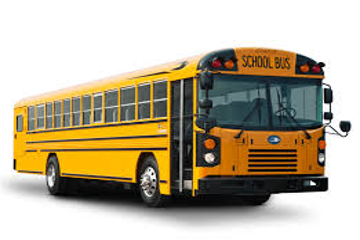


Image Path: /content/schoolBus.jpeg
Top-5 ImageNet predictions:
1. school bus: 99.99%
2. passenger car, coach, carriage: 0.00%
3. minibus: 0.00%
4. trolleybus, trolley coach, trackless trolley: 0.00%
5. amphibian, amphibious vehicle: 0.00%


In [7]:
import os
import torch
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification

MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

image_processor = AutoImageProcessor.from_pretrained(MODEL_ID)
classifier = AutoModelForImageClassification.from_pretrained(MODEL_ID).to(DEVICE)
classifier.eval()

IMAGE_PATH = "/content/schoolBus.jpeg"

if not os.path.exists(IMAGE_PATH):
    print(f"Error: Image not found at '{IMAGE_PATH}'")
else:
    image = Image.open(IMAGE_PATH).convert("RGB")
    display(image.resize((360, 240)))

    inputs = image_processor(images=image, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        logits = classifier(**inputs).logits[0]
        probs = torch.softmax(logits, dim=0)
        top_probs, top_ids = torch.topk(probs, 5)

    print(f"\nImage Path: {IMAGE_PATH}")
    print("Top-5 ImageNet predictions:")
    for rank, (idx, prob) in enumerate(zip(top_ids.tolist(), top_probs.tolist()), start=1):
        print(f"{rank}. {classifier.config.id2label[idx]}: {prob:.2%}")